In [68]:
import numpy as np 
import pandas as pd

In [69]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [70]:
import tensorflow
import keras
from keras.layers import Dense
from keras import Sequential

In [71]:
X,y = make_moons(n_samples=100,noise=0.25,random_state=42)

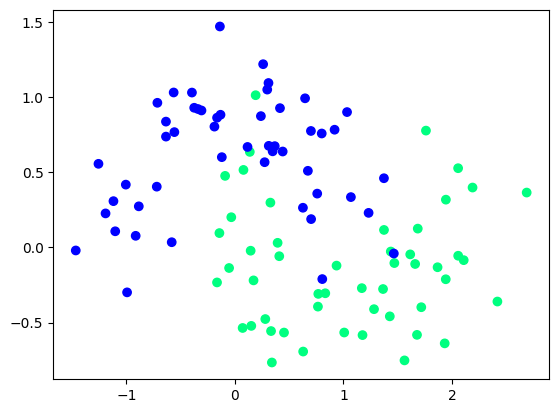

In [72]:
plt.scatter(X[:,0],X[:,1],c=y,cmap="winter")

In [73]:
model1 = Sequential()

In [74]:
model1.add(Dense(128,activation="relu",input_dim=2))
model1.add(Dense(128,activation='relu'))
model1.add(Dense(1,activation='sigmoid'))

D:\Deep_Learning\.venv_tf1\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
from keras.optimizers import Adam

In [76]:
adam = Adam(learning_rate=0.01)

In [77]:
model1.compile(loss='binary_crossentropy',optimizer=adam,metrics=['accuracy'])

In [78]:
from sklearn.model_selection import train_test_split

In [79]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=30)

In [82]:
hist1 = model1.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100,verbose=True)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - accuracy: 0.6094 - loss: 0.6343 - val_accuracy: 0.8500 - val_loss: 0.3484
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8188 - loss: 0.4359 - val_accuracy: 0.9000 - val_loss: 0.2225
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8313 - loss: 0.3852 - val_accuracy: 0.9500 - val_loss: 0.2123
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8414 - loss: 0.4036 - val_accuracy: 0.9500 - val_loss: 0.1544
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8586 - loss: 0.3440 - val_accuracy: 0.9500 - val_loss: 0.1565
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8352 - loss: 0.3718 - val_accuracy: 0.9500 - val_loss: 0.1783
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8547 - loss: 0.3155 - val_accuracy: 0.9500 - val_loss: 0.1838
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8633 - loss: 0.3194 - val_accuracy: 0.9500 - val_loss

In [83]:
from mlxtend.plotting import plot_decision_regions

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 869us/step


<Axes: >

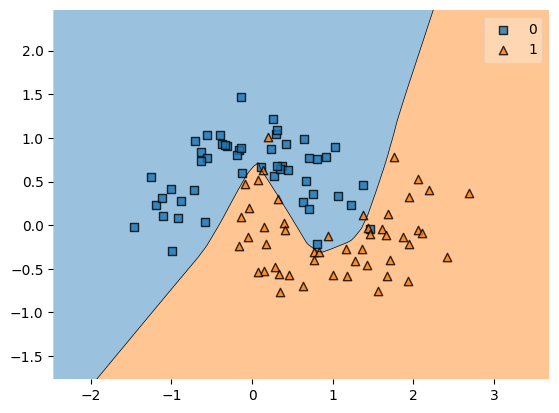

In [84]:
plot_decision_regions(X,y,model1)

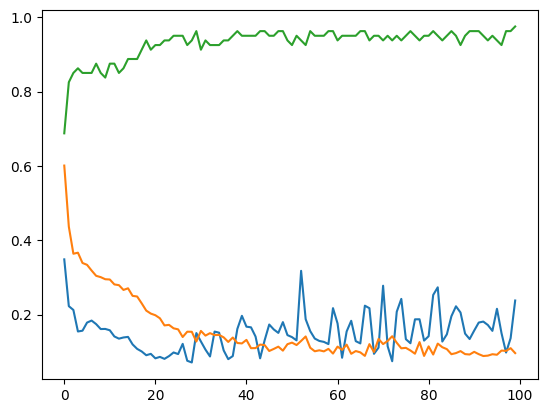

In [85]:
plt.plot(hist1.history['val_loss'])
plt.plot(hist1.history['loss'])
plt.plot(hist1.history['accuracy'])

In [86]:
hist1.history['val_accuracy'][-1]

0.949999988079071

## Implementation of regularization

In [87]:
model2 = Sequential()

In [88]:
model2.add(Dense(128,activation='relu',input_dim=2,kernel_regularizer=tensorflow.keras.regularizers.l2(0.03)))
model2.add(Dense(128,activation='relu',input_dim=2,kernel_regularizer=tensorflow.keras.regularizers.l2(0.03)))
model2.add(Dense(1,activation="sigmoid"))

In [89]:
model2.compile(loss='binary_crossentropy',optimizer="adam",metrics=['accuracy'])

In [90]:
hist2 = model2.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.3031 - loss: 4.6893 - val_accuracy: 0.3500 - val_loss: 4.4887
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.4469 - loss: 4.4308 - val_accuracy: 0.6500 - val_loss: 4.2449
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7312 - loss: 4.2070 - val_accuracy: 0.9500 - val_loss: 4.0138
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.8359 - loss: 3.9842 - val_accuracy: 0.9000 - val_loss: 3.7969
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8344 - loss: 3.7820 - val_accuracy: 0.9000 - val_loss: 3.5943
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8188 - loss: 3.5854 - val_accuracy: 0.9000 - val_loss: 3.4029
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7953 - loss: 3.4036 - val_accuracy: 0.9000 - val_loss: 3.2209
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.8320 - loss: 3.2210 - val_accuracy: 0.9000 - val_loss

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 10s 997us/step


<Axes: >

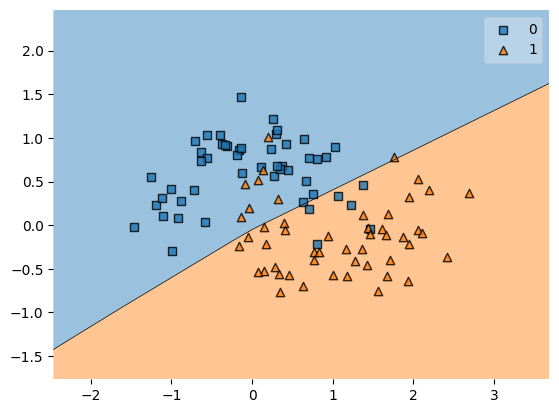

In [91]:
plot_decision_regions(X,y,model2)

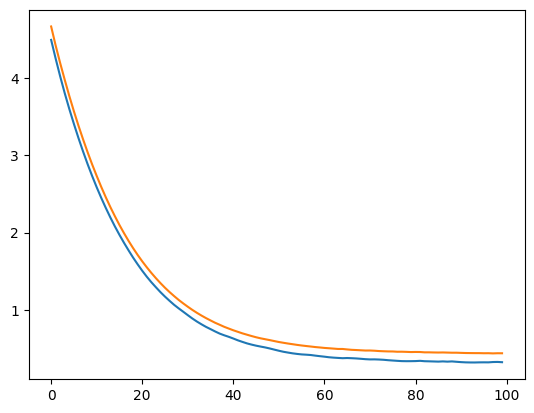

In [92]:
plt.plot(hist2.history['val_loss'])
plt.plot(hist2.history['loss'])

In [93]:
model1_weight_layer1  = model1.get_weights()[0].reshape(256)
model2_weight_layer1 =  model2.get_weights()[0].reshape(256)

In [94]:
import seaborn as sns

<Axes: >

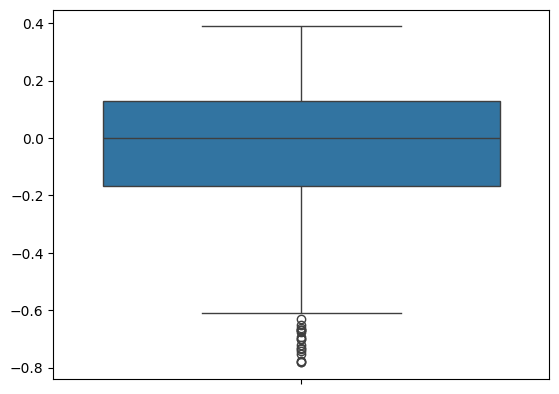

In [95]:
sns.boxplot(model1_weight_layer1)
# This give the range of all weights (There is outliers) -2 to 1

<Axes: >

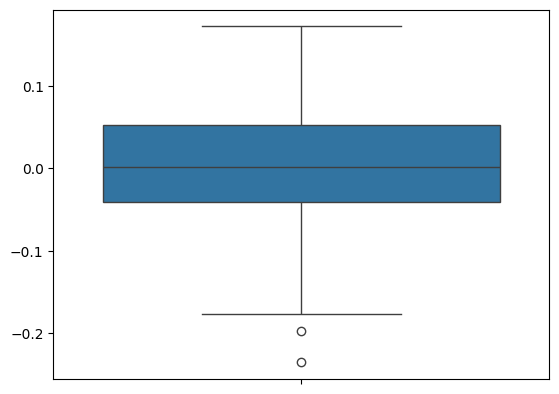

In [96]:
sns.boxplot(model2_weight_layer1)
# Most of the weights shrink tends to zero -0.6 to 0.4

In [97]:
model1_weight_layer1.max()

np.float32(0.38876876)

In [98]:
model2_weight_layer1.max()

np.float32(0.17306422)

In [99]:
model1_weight_layer1.min()

np.float32(-0.7819547)

In [100]:
model2_weight_layer1.min()

np.float32(-0.23607655)

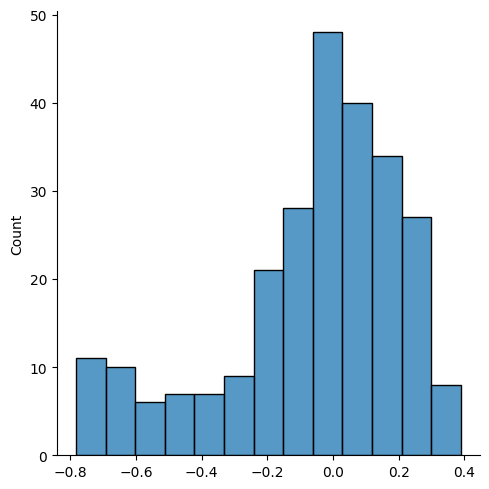

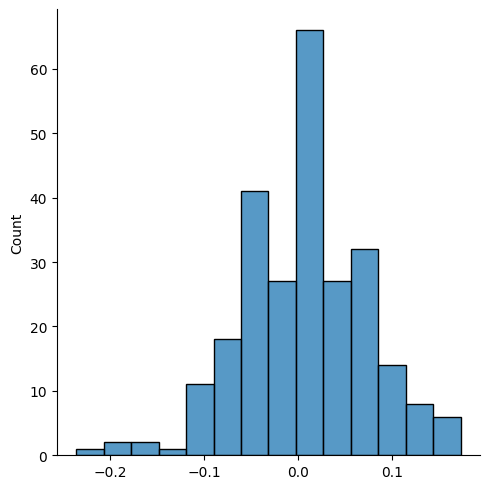

In [101]:
sns.displot(model1_weight_layer1)
sns.displot(model2_weight_layer1)
# prob density function model2 is very close to zero 
# but model1 give the range of values 

## l2 is better and usefuL L1 is also used but not more than l2